# Stage 3 — Model Development & Tracking

In [3]:
import sys
import importlib

sys.path.insert(0, ".")

import data_prep as dp
import config as cfg

importlib.reload(dp)
importlib.reload(cfg)

print("data_prep loaded:", hasattr(dp, "prepare"))
print("config loaded:", cfg.DATA_PATH)

data_prep loaded: True
config loaded: diabetic_data.csv


In [1]:
import config as cfg

print("Config loaded from:")
print(cfg.__file__)

print("\nDATA_PATH:", cfg.DATA_PATH)
print("RANDOM_STATE:", cfg.RANDOM_STATE)

Config loaded from:
c:\Users\368435\Music\MlProjects\hospital-readmission-prediction\config.py

DATA_PATH: diabetic_data.csv
RANDOM_STATE: 42


In [4]:
X, y, X_train, X_val, X_test, y_train, y_val, y_test = dp.prepare(
    cfg.DATA_PATH
)

print("========================================")
print("Stage 3 Data Preparation Validation")
print("========================================")

print("Full dataset:", X.shape)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nPositive rates:")
print("Full:", round(y.mean() * 100, 2), "%")
print("Train:", round(y_train.mean() * 100, 2), "%")
print("Validation:", round(y_val.mean() * 100, 2), "%")
print("Test:", round(y_test.mean() * 100, 2), "%")

c:\Users\368435\Music\MlProjects\hospital-readmission-prediction\data_prep.py:75: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, na_values=["?"])


Stage 3 Data Preparation Validation
Full dataset: (69973, 54)
Train: (48981, 54)
Validation: (10496, 54)
Test: (10496, 54)

Target distribution:
target
0    63696
1     6277
Name: count, dtype: int64

Positive rates:
Full: 8.97 %
Train: 8.97 %
Validation: 8.97 %
Test: 8.97 %


In [6]:
print("========================================")
print("Preprocessor Validation")
print("========================================")

print("Preprocessor type:")
print(type(preprocessor))

print("\nTransformer names:")
print([name for name, _, _ in preprocessor.transformers])

print("\nNumber of transformers:")
print(len(preprocessor.transformers))

Preprocessor Validation
Preprocessor type:
<class 'sklearn.compose._column_transformer.ColumnTransformer'>

Transformer names:
['numeric', 'categorical']

Number of transformers:
2


In [7]:
numeric_features, categorical_features = dp.get_feature_lists(X_train)

print("========================================")
print("Feature Coverage Validation")
print("========================================")

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(numeric_features) + len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nExcluded raw features:")
excluded_raw = [
    "age",
    "diag_1",
    "diag_2",
    "diag_3",
    "medical_specialty"
]

print([
    col for col in excluded_raw
    if col in X_train.columns
])

print("\nTarget/ID leakage check:")
leakage_columns = [
    "target",
    "encounter_id",
    "patient_nbr",
    "readmitted"
]

print([
    col for col in leakage_columns
    if col in numeric_features + categorical_features
])

Feature Coverage Validation
Numeric features: 11
Categorical features: 35
Total features: 46

Numeric features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_midpoint', 'total_prior_visits', 'medication_change_count']

Excluded raw features:
['age', 'diag_1', 'diag_2', 'diag_3', 'medical_specialty']

Target/ID leakage check:
[]


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline_preprocessor = dp.build_preprocessor(X_train)

baseline_model = Pipeline([
    ("preprocessor", baseline_preprocessor),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=cfg.RANDOM_STATE
        )
    )
])

print("========================================")
print("Logistic Regression Baseline")
print("========================================")

print("Pipeline created successfully")
print("Steps:", list(baseline_model.named_steps.keys()))

Logistic Regression Baseline
Pipeline created successfully
Steps: ['preprocessor', 'classifier']


In [9]:
print("========================================")
print("Training Logistic Regression Baseline")
print("========================================")

baseline_model.fit(X_train, y_train)

print("Baseline model training completed successfully.")

Training Logistic Regression Baseline
Baseline model training completed successfully.


In [10]:
print("========================================")
print("Generating Validation Predictions")
print("========================================")

y_val_proba = baseline_model.predict_proba(X_val)[:, 1]
y_val_pred = baseline_model.predict(X_val)

print("Validation predictions generated successfully.")

print("\nPrediction shapes:")
print("Probability predictions:", y_val_proba.shape)
print("Class predictions:", y_val_pred.shape)

print("\nFirst 10 predicted probabilities:")
print(y_val_proba[:10])

print("\nFirst 10 predicted classes:")
print(y_val_pred[:10])

Generating Validation Predictions
Validation predictions generated successfully.

Prediction shapes:
Probability predictions: (10496,)
Class predictions: (10496,)

First 10 predicted probabilities:
[0.61199846 0.47634658 0.69320518 0.43032186 0.45762295 0.61220296
 0.60404742 0.34178658 0.38868058 0.41100296]

First 10 predicted classes:
[1 0 1 0 0 1 1 0 0 0]


In [11]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score
)

print("========================================")
print("Logistic Regression - Validation Metrics")
print("========================================")

baseline_roc_auc = roc_auc_score(y_val, y_val_proba)
baseline_pr_auc = average_precision_score(y_val, y_val_proba)
baseline_recall = recall_score(y_val, y_val_pred)
baseline_precision = precision_score(y_val, y_val_pred)
baseline_f1 = f1_score(y_val, y_val_pred)
baseline_accuracy = accuracy_score(y_val, y_val_pred)

print(f"ROC-AUC  : {baseline_roc_auc:.4f}")
print(f"PR-AUC   : {baseline_pr_auc:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")
print(f"Accuracy : {baseline_accuracy:.4f}")

Logistic Regression - Validation Metrics
ROC-AUC  : 0.6415
PR-AUC   : 0.1705
Recall   : 0.5276
Precision: 0.1359
F1 Score : 0.2162
Accuracy : 0.6566


In [12]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [13]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("========================================")
print("XGBoost Class Weight")
print("========================================")

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 4))

XGBoost Class Weight
Negative samples: 44587
Positive samples: 4394
scale_pos_weight: 10.1472


In [14]:
xgb_preprocessor = dp.build_preprocessor(X_train)

xgb_model = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "classifier",
        xgb.XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            min_child_weight=5,
            reg_lambda=2.0,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=cfg.RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1
        )
    )
])

print("========================================")
print("XGBoost Advanced Pipeline")
print("========================================")

print("Pipeline created successfully")
print("Steps:", list(xgb_model.named_steps.keys()))

XGBoost Advanced Pipeline
Pipeline created successfully
Steps: ['preprocessor', 'classifier']


In [15]:
print("========================================")
print("Training XGBoost Advanced Model")
print("========================================")

xgb_model.fit(X_train, y_train)

print("XGBoost model training completed successfully.")

Training XGBoost Advanced Model
XGBoost model training completed successfully.


In [16]:
print("========================================")
print("Generating XGBoost Validation Predictions")
print("========================================")

xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_val_pred = xgb_model.predict(X_val)

print("Validation predictions generated successfully.")

print("\nPrediction shapes:")
print("Probability predictions:", xgb_val_proba.shape)
print("Class predictions:", xgb_val_pred.shape)

print("\nFirst 10 predicted probabilities:")
print(xgb_val_proba[:10])

print("\nFirst 10 predicted classes:")
print(xgb_val_pred[:10])

Generating XGBoost Validation Predictions
Validation predictions generated successfully.

Prediction shapes:
Probability predictions: (10496,)
Class predictions: (10496,)

First 10 predicted probabilities:
[0.6066331  0.46403617 0.5617651  0.4687374  0.39295933 0.5529243
 0.4322376  0.3416788  0.37793976 0.37750623]

First 10 predicted classes:
[1 0 1 0 0 1 0 0 0 0]


In [17]:
print("========================================")
print("XGBoost - Validation Metrics")
print("========================================")

xgb_roc_auc = roc_auc_score(y_val, xgb_val_proba)
xgb_pr_auc = average_precision_score(y_val, xgb_val_proba)
xgb_recall = recall_score(y_val, xgb_val_pred)
xgb_precision = precision_score(y_val, xgb_val_pred)
xgb_f1 = f1_score(y_val, xgb_val_pred)
xgb_accuracy = accuracy_score(y_val, xgb_val_pred)

print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"Accuracy : {xgb_accuracy:.4f}")

XGBoost - Validation Metrics
ROC-AUC  : 0.6502
PR-AUC   : 0.1814
Recall   : 0.5191
Precision: 0.1413
F1 Score : 0.2221
Accuracy : 0.6737


In [19]:
import pandas as pd 

In [20]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],
    "ROC-AUC": [
        baseline_roc_auc,
        xgb_roc_auc
    ],
    "PR-AUC": [
        baseline_pr_auc,
        xgb_pr_auc
    ],
    "Recall": [
        baseline_recall,
        xgb_recall
    ],
    "Precision": [
        baseline_precision,
        xgb_precision
    ],
    "F1": [
        baseline_f1,
        xgb_f1
    ],
    "Accuracy": [
        baseline_accuracy,
        xgb_accuracy
    ]
})

comparison = comparison.set_index("Model")

print("========================================")
print("Model Comparison")
print("========================================")

print(comparison.round(4))

print("\nSelected model based on validation ROC-AUC:")
print(comparison["ROC-AUC"].idxmax())

Model Comparison
                     ROC-AUC  PR-AUC  Recall  Precision      F1  Accuracy
Model                                                                    
Logistic Regression   0.6415  0.1705  0.5276     0.1359  0.2162    0.6566
XGBoost               0.6502  0.1814  0.5191     0.1413  0.2221    0.6737

Selected model based on validation ROC-AUC:
XGBoost


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, xgb_val_pred)

print("========================================")
print("XGBoost - Validation Confusion Matrix")
print("========================================")

print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nTotal:", tn + fp + fn + tp)

XGBoost - Validation Confusion Matrix
[[6582 2972]
 [ 453  489]]

TN: 6582
FP: 2972
FN: 453
TP: 489

Total: 10496


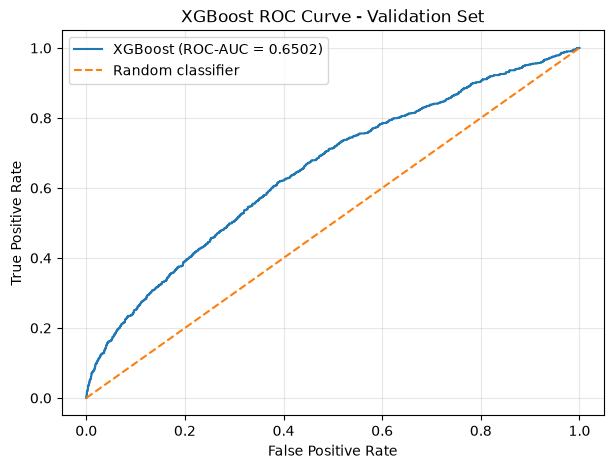

In [22]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_val,
    xgb_val_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (ROC-AUC = {xgb_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve - Validation Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

XGBoost - Validation Confusion Matrix Plot


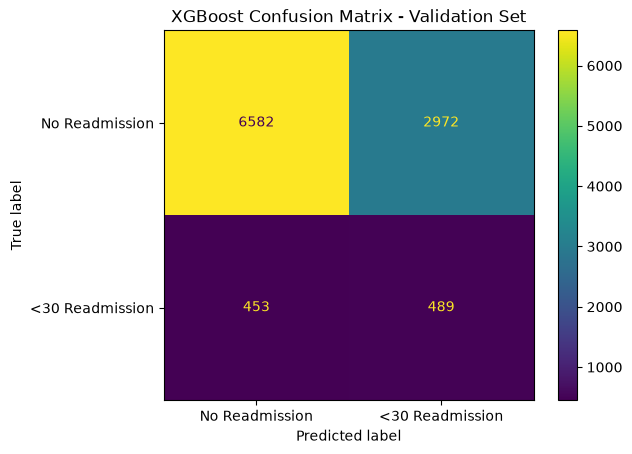

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("========================================")
print("XGBoost - Validation Confusion Matrix Plot")
print("========================================")

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Readmission", "<30 Readmission"]
).plot()

plt.title("XGBoost Confusion Matrix - Validation Set")
plt.show()

In [24]:
print("========================================")
print("Generating XGBoost Test Predictions")
print("========================================")

xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_pred = xgb_model.predict(X_test)

print("Test predictions generated successfully.")

print("\nPrediction shapes:")
print("Probability predictions:", xgb_test_proba.shape)
print("Class predictions:", xgb_test_pred.shape)

Generating XGBoost Test Predictions
Test predictions generated successfully.

Prediction shapes:
Probability predictions: (10496,)
Class predictions: (10496,)


In [25]:
print("========================================")
print("XGBoost - Final Test Metrics")
print("========================================")

xgb_test_roc_auc = roc_auc_score(y_test, xgb_test_proba)
xgb_test_pr_auc = average_precision_score(y_test, xgb_test_proba)
xgb_test_recall = recall_score(y_test, xgb_test_pred)
xgb_test_precision = precision_score(y_test, xgb_test_pred)
xgb_test_f1 = f1_score(y_test, xgb_test_pred)
xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred)

print(f"ROC-AUC  : {xgb_test_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_test_pr_auc:.4f}")
print(f"Recall   : {xgb_test_recall:.4f}")
print(f"Precision: {xgb_test_precision:.4f}")
print(f"F1 Score : {xgb_test_f1:.4f}")
print(f"Accuracy : {xgb_test_accuracy:.4f}")

XGBoost - Final Test Metrics
ROC-AUC  : 0.6557
PR-AUC   : 0.1814
Recall   : 0.5197
Precision: 0.1418
F1 Score : 0.2228
Accuracy : 0.6749


In [26]:
test_cm = confusion_matrix(y_test, xgb_test_pred)

tn_test, fp_test, fn_test, tp_test = test_cm.ravel()

print("========================================")
print("XGBoost - Final Test Confusion Matrix")
print("========================================")

print(test_cm)

print("\nTN:", tn_test)
print("FP:", fp_test)
print("FN:", fn_test)
print("TP:", tp_test)

print("\nTotal:", tn_test + fp_test + fn_test + tp_test)

XGBoost - Final Test Confusion Matrix
[[6595 2960]
 [ 452  489]]

TN: 6595
FP: 2960
FN: 452
TP: 489

Total: 10496


In [28]:
import mlflow

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.0


In [29]:
from pathlib import Path

print("========================================")
print("MLflow Project Files Check")
print("========================================")

project_root = Path.cwd()

print("Current project:")
print(project_root)

print("\nMLflow-related files:")
mlflow_files = [
    p for p in project_root.iterdir()
    if "mlflow" in p.name.lower()
]

if mlflow_files:
    for p in mlflow_files:
        print("-", p.name)
else:
    print("No MLflow-related files found.")

MLflow Project Files Check
Current project:
c:\Users\368435\Music\MlProjects\hospital-readmission-prediction

MLflow-related files:
No MLflow-related files found.
